# Assignment 15 - Modelling a dense NN classifying squats 0-5

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from IPython.display import HTML
import joblib
import random
import torch.nn.functional as F
from sklearn.metrics import f1_score
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from torchinfo import summary
from datetime import datetime
import json
import copy
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    mean_absolute_error,
    r2_score
)


if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")

random_seed = 42 
RANDOM_SEED = random_seed   
torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

## Define data preparation functions

In [2]:
def load(files, data_dir):
    dataframes = []

    for f in files:
        path = os.path.join(data_dir, f)   
        df = pd.read_csv(path)

        # Get rid of trailing whitespace
        df.columns = df.columns.str.strip()           
        dataframes.append(df)             

    combined = pd.concat(dataframes, ignore_index=True)  # combine all

    return combined

def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files

def mirror_dataframe(df, mirror_x=True, mirror_y=True, mirror_z=True):
    """
    Mirror pose data by swapping left/right joints.

    Assumes column format: frameX_joint_coord
    """

    df_copy = df.copy()

    mirror_pairs = [
        ("left_shoulder", "right_shoulder"),
        ("left_elbow", "right_elbow"),
        ("left_hand", "right_hand"),
        ("left_hip", "right_hip"),
        ("left_knee", "right_knee"),
        ("left_foot", "right_foot"),
    ]

    for col in df.columns:
        parts = col.split("_")

        # Example: frame0_left_knee_x
        frame = parts[0]
        coord = parts[-1]
        joint = "_".join(parts[1:-1])

        for left, right in mirror_pairs:

            if joint == left:
                mirrored_col = f"{frame}_{right}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

            elif joint == right:
                mirrored_col = f"{frame}_{left}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

    return df_copy

def augment_with_noise(X, noise_std=0.005):
    noise = np.random.normal(0, noise_std, X.shape)
    return X + noise

## Load and prepare flat data

In [3]:
data_dir = "../../MainProject/data/mediapipe_score_fixed_c"
train_prop = 0.8
val_prop = 0
train_files, test_files = split_csvfiles(data_dir, random_seed, train_prop, val_prop)

train_data = load(train_files, data_dir)
test_data = load(test_files, data_dir)

y_train = train_data["target"]
x_train = train_data.drop(columns = "target")

y_test = test_data["target"]
x_test = test_data.drop(columns = "target")

# From now on and below the data prep is for post-CV usage

# Augment training data with mirroring
x_train_aug = pd.concat([x_train, mirror_dataframe(x_train)])
y_train_aug = pd.concat([y_train, y_train])

# Augment training data with noise
x_train_aug = pd.concat([x_train_aug, augment_with_noise(x_train_aug)])
y_train_aug = pd.concat([y_train_aug, y_train_aug])

# Scale data
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train_aug)
x_test_sc = scaler.transform(x_test)

# Add some noise to training data to improve generalization
x_train_noise = augment_with_noise(x_train_sc)


# Make all numpy to keep consistency
x_train_np = np.asarray(x_train_noise)
y_train_np = np.asarray(y_train_aug)
x_test_np = np.asarray(x_test_sc)
y_test_np  = np.asarray(y_test)

# Tensorize
x_train_prep = torch.tensor(x_train_np, dtype=torch.float32).to(device)
x_test_prep   = torch.tensor(x_test_np, dtype=torch.float32).to(device)
y_train_prep = torch.tensor(y_train_np, dtype=torch.float32).to(device).view(-1, 1)
y_test_prep = torch.tensor(y_test_np, dtype=torch.float32).to(device).view(-1, 1)

# Check dimensions for the preopared data
print("Data dimensions for fully prepared data")
print(f"Total amount of features: {x_train_prep.shape[1]}")
print(f"Total amount of samples: {x_train_prep.shape[0] + x_test_prep.shape[0]}")

Data dimensions for fully prepared data
Total amount of features: 1170
Total amount of samples: 591


# Functions for modelling

In [4]:
# Define squat classifier regression model
class SquatRegDense(nn.Module):
    def __init__(self, input_dim, hidden_layers: list, activation="relu", dropout=0.0):
        super().__init__()

        layers = []
        activations = {"relu": nn.ReLU(),
                       "tanh": nn.Tanh(),
                       "gelu": nn.GELU(),
                       "leaky_relu": nn.LeakyReLU()
                       }
        
        prev_size = input_dim

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(activations[activation])

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size

        
        # Output layer
        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)
        self.network.apply(init_weights)

    def forward(self, x):
        return self.network(x)



def build_dense_model(config, input_size):
    return SquatRegDense(
        input_dim=input_size,
        hidden_layers=config["layers"],
        activation=config["activation"],
        dropout=config["dropout"]
    ).to(device)


# Define initial weights and biases
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight)
        nn.init.zeros_(m.bias)


# Full batch since it's faster on my cpu? 
def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn):

    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    epochs = config["epochs"]

    best_val_mse = float("inf")
    best_state = copy.deepcopy(model.state_dict())

    patience = 10
    epochs_no_improve = 0

    # Convergence tracking
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mse": []
    }

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        predictions = model(x_train)

        train_loss = loss_fn(predictions, y_train)
        train_loss.backward()
        optimizer.step()

        # Validation with mse as metric
        model.eval()
        with torch.no_grad():
            val_predictions = model(x_val)
            val_loss = loss_fn(val_predictions, y_val)

            val_mse = val_loss.item()


        # Store history for each epoch
        history["train_loss"].append(train_loss.item())
        history["val_loss"].append(val_loss.item())
        history["val_mse"].append(val_mse)

        # Early stopping
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    # Load best weights
    model.load_state_dict(best_state)

    return best_val_mse, model, history

# Cross validation
def cross_validate_model(config, X, y, loss_fn, input_size, n_splits=10):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_mse_scores = []
    fold_histories = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        # Split data
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # --Augmentate for each individual fold to avoid leakage--
        # Mirror augmentation
        X_train = pd.concat([X_train, mirror_dataframe(X_train)])
        y_train = np.concatenate([y_train, y_train])

        # Noise augmentation
        X_train = pd.concat([X_train, augment_with_noise(X_train)])
        y_train = np.concatenate([y_train, y_train])

        # --Scale for each fold  to avoid data leakage-- (df -> np.array)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)

        # Convert the y array to numpy arrays too
        y_train = np.asarray(y_train)
        y_val   = np.asarray(y_val)

        # Convert to tensors
        X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
        X_val   = torch.tensor(X_val, dtype=torch.float32).to(device)
        y_train = torch.tensor(y_train, dtype=torch.float32).to(device).view(-1, 1)
        y_val = torch.tensor(y_val, dtype=torch.float32).to(device).view(-1, 1)

        # Build fresh model
        model = build_dense_model(config, input_size)

        # Train
        val_mse, model, history = train_one_model(
            model, config,
            X_train, y_train,
            X_val, y_val,
            loss_fn
        )

        fold_mse_scores.append(val_mse)
        fold_histories.append(history)


    # Aggregate results
    mean_mse = np.mean(fold_mse_scores)
    std_mse  = np.std(fold_mse_scores)

    return {
        "cv_mean_mse": mean_mse,
        "mse_std": std_mse,
        "fold_scores": fold_mse_scores
    }

## Functions for model handling

In [5]:
def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")

    if not os.path.exists(path):
        return None

    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None

# Changed to be mse based

def save_champion_model(champion_dir, metadata_dir, model, model_name, mse, mae, r2, hyperparameters):
    model_path = os.path.join(champion_dir, "champion_model.pt")
    info_path = os.path.join(metadata_dir, "champion_info.json")

    # Save model weights
    torch.save(model.state_dict(), model_path)

    # Save metadata
    info = {
        "model_name": model_name,
        "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "mse": float(mse),
        "mae": float(mae),
        "r2": r2,
        "hyperparameters": hyperparameters
    }

    with open(info_path, "w") as f:
        json.dump(info, f, indent=2)

    print("New champion model saved!")


# MSE loss based
def update_champion(metadata_dir, champion_dir, model, model_name, mse, mae, r2, hyperparameters):
    current = load_champion_info(metadata_dir)

    if current is None:
        print("No champion found --> saving first model")
        save_champion_model(champion_dir, metadata_dir, model, model_name, mse, mae, r2, hyperparameters)

    elif mse < current["mse"]:
        print(f"New model is better (mse {mse} < {current['mse']})")
        save_champion_model(champion_dir, metadata_dir, model, model_name, mse, mae, r2, hyperparameters)

    else:
        print(f"Model NOT better (mse {mse} > {current['mse']})")

## CV grid search

In [6]:
param_grid = {"layers": [[128, 64], [256, 128, 64], [128, 64, 32]],
              "lr": [0.001, 0.005],
              "dropout": [0.2, 0.1, 0.0],
              "activation": ["relu", "leaky_relu"],
              "epochs": [100, 200, 300]
            }

trial = 0
best_mse = float("inf")
best_config = None
loss_func = nn.MSELoss()

# Make configuration of every existing combinations of grid values
for values in product(
    param_grid["layers"],
    param_grid["lr"],
    param_grid["dropout"],
    param_grid["activation"],
    param_grid["epochs"]
    ):

    config = {
        "layers": values[0],
        "lr": values[1],
        "dropout": values[2],
        "activation": values[3],
        "epochs": values[4]
        }

    print(f"\nTrial: {trial + 1}")
    print(config)

    # Extract the number of features
    input_size = x_train.shape[1]

    # Cross validation
    results = cross_validate_model(config, x_train, y_train, loss_func, input_size)

    mse_score = results["cv_mean_mse"]
    mse_std = results["mse_std"]
    fold_scores = results["fold_scores"]

    print(f"MSE fold scores: {fold_scores}")
    print(f"CV mean MSE: {mse_score} +- {mse_std}")

    # Update best config
    if mse_score < best_mse:
        best_mse = mse_score
        best_config = config
    
    trial += 1


Trial: 1
{'layers': [128, 64], 'lr': 0.001, 'dropout': 0.2, 'activation': 'relu', 'epochs': 100}
MSE fold scores: [0.5648484826087952, 0.41926151514053345, 0.7009933590888977, 0.43765583634376526, 0.3429778218269348, 0.7578678727149963, 0.32804861664772034, 0.2523803412914276, 0.7033754587173462, 0.9165676832199097]
CV mean MSE: 0.5423976987600326 +- 0.2083166567791958

Trial: 2
{'layers': [128, 64], 'lr': 0.001, 'dropout': 0.2, 'activation': 'relu', 'epochs': 200}
MSE fold scores: [0.4426199495792389, 1.1111713647842407, 0.2610340714454651, 0.2291523516178131, 0.3775375187397003, 0.5635029077529907, 0.29198938608169556, 0.34809961915016174, 0.5537656545639038, 1.3751250505447388]
CV mean MSE: 0.5553997874259948 +- 0.3647877637764574

Trial: 3
{'layers': [128, 64], 'lr': 0.001, 'dropout': 0.2, 'activation': 'relu', 'epochs': 300}
MSE fold scores: [0.548566460609436, 0.724448561668396, 0.3620016276836395, 0.383230596780777, 0.307943731546402, 0.5339111089706421, 0.580600380897522, 0.29

## Get best config - rebuild and retrain on all of the training data

In [10]:
print(best_config)
input_size = x_train.shape[1]

# Re-build best config model
model = build_dense_model(best_config, input_size)

# Make train/val out of training data for re-training purposes
x_tr, x_val, y_tr, y_val = train_test_split(x_train_prep, y_train_prep, test_size = 0.1, random_state = random_seed)

# Re-train
val_mse, best_model, history = train_one_model(model, best_config, x_tr, y_tr, x_val, y_val, nn.MSELoss())

print(f"Training mse: {val_mse}")

# Summarize best model
summary(best_model, input_size=(1, input_size), col_names=["input_size", "output_size", "num_params", "trainable"])

{'layers': [256, 128, 64], 'lr': 0.001, 'dropout': 0.1, 'activation': 'relu', 'epochs': 100}
Training mse: 0.13711699843406677


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
SquatRegDense                            [1, 1170]                 [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 1170]                 [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 1170]                 [1, 256]                  299,776                   True
│    └─ReLU: 2-2                         [1, 256]                  [1, 256]                  --                        --
│    └─Dropout: 2-3                      [1, 256]                  [1, 256]                  --                        --
│    └─Linear: 2-4                       [1, 256]                  [1, 128]                  32,896                    True
│    └─ReLU: 2-5                         [1, 128]                  [1, 128]                  --                        --
│    └─Dr

## Evaluate on test data and save if champion

torch.Size([35, 1])
torch.Size([35, 1])
TEST EVALUATION
Test MSE: 0.3207944929599762
Test MAE: 0.43229562044143677
Test R2: 0.6275323629379272


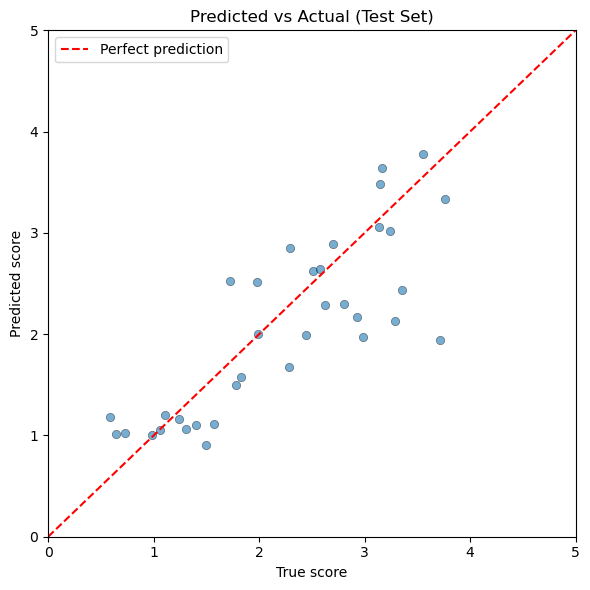

New model is better (mse 0.3207944929599762 < 0.43837180733680725)
New champion model saved!


In [ ]:
best_model.eval()
with torch.no_grad():
    predictions = best_model(x_test_prep)

    print(predictions.shape)
    print(y_test_prep.shape)
    
    # Evaluate against
    loss_func = nn.MSELoss()
    test_mse = loss_func(predictions, y_test_prep)
    test_mae = mean_absolute_error(predictions.detach().numpy(), y_test_prep.detach().numpy())
    test_r2 = r2_score(y_test_prep.detach().numpy(), predictions.detach().numpy())


print("TEST EVALUATION")
print(f"Test MSE: {test_mse}")
print(f"Test MAE: {test_mae}")
print(f"Test R2: {test_r2}")

# Scatter: predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test_prep.detach().numpy(), predictions.detach().numpy(), alpha=0.6, edgecolors='k', linewidths=0.4)
lims = [0, 5]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("True score"); plt.ylabel("Predicted score")
plt.title("Predicted vs Actual (Test Set)")
plt.legend(); plt.tight_layout(); plt.show()

# Save model is champion
metadata_dir = "../Dense_Squat_Regression_Model/metadata"
champion_dir = "../Dense_Squat_Regression_Model/champion_model"

os.makedirs(metadata_dir, exist_ok= True)
os.makedirs(champion_dir, exist_ok = True)


update_champion(
    metadata_dir=metadata_dir,
    champion_dir=champion_dir,
    model=best_model,
    model_name="denseSquatReg",
    mse=test_mse,
    mae=test_mae,
    r2=test_r2,
    hyperparameters=best_config
)

## Load champion and evaluate against test set

DENSE CHAMPION MODEL SUMMARY
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
SquatRegDense                            [1, 1170]                 [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 1170]                 [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 1170]                 [1, 256]                  299,776                   True
│    └─ReLU: 2-2                         [1, 256]                  [1, 256]                  --                        --
│    └─Dropout: 2-3                      [1, 256]                  [1, 256]                  --                        --
│    └─Linear: 2-4                       [1, 256]                  [1, 128]                  32,896                    True
│    └─ReLU: 2-5                         [1, 128]                  [1, 128]                  --       

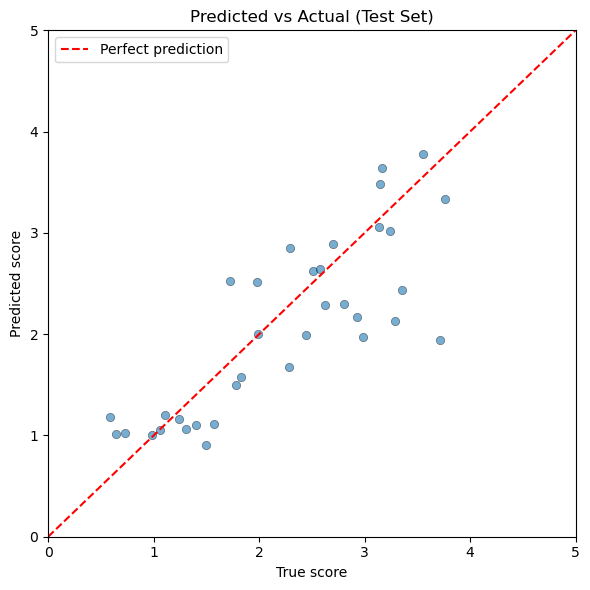

In [15]:
metadata_dir = "../Dense_Squat_Regression_Model/metadata"
champion_dir = "../Dense_Squat_Regression_Model/champion_model"

model_path = os.path.join(champion_dir, "champion_model.pt")
info_path = os.path.join(metadata_dir, "champion_info.json")

state_dict = torch.load(model_path, map_location=device)

with open(info_path, "r") as f:
    champion_info = json.load(f)

champion_config = champion_info["hyperparameters"]
input_size = x_test_prep.shape[1]


# Re-build trained model from the files
champion_model = build_dense_model(champion_config, input_size)
champion_model.load_state_dict(state_dict)
champion_model.to(device)

# Summarize champion model
model_summary = summary(champion_model, input_size=(1, input_size), col_names=["input_size", "output_size", "num_params", "trainable"])

print("DENSE CHAMPION MODEL SUMMARY")
print(model_summary)

champion_model.eval()
with torch.no_grad():
    predictions = champion_model(x_test_prep)

    print(predictions.shape)
    print(y_test_prep.shape)
    
    # Evaluate against
    loss_func = nn.MSELoss()
    test_mse = loss_func(predictions, y_test_prep)
    test_mae = mean_absolute_error(predictions.detach().numpy(), y_test_prep.detach().numpy())
    test_r2 = r2_score(y_test_prep.detach().numpy(), predictions.detach().numpy())


print("\n\nTEST EVALUATION")
print(f"Test MSE: {test_mse}")
print(f"Test MAE: {test_mae}")
print(f"Test R2: {test_r2}")

# Scatter: predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test_prep.detach().numpy(), predictions.detach().numpy(), alpha=0.6, edgecolors='k', linewidths=0.4)
lims = [0, 5]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("True score"); plt.ylabel("Predicted score")
plt.title("Predicted vs Actual (Test Set)")
plt.legend(); plt.tight_layout(); plt.show()